<a href="https://colab.research.google.com/github/lasyaEd/computerVision/blob/main/MidtermTask123ACV_ledunuri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Data**

##✅ Step 1: Setup & Data Preparation

In [1]:
# Mount your Google Drive if you'd like to store the dataset there
from google.colab import drive
drive.mount('/content/drive')

# Download the zip file from Kaggle
!pip install -q kaggle

# Upload your kaggle.json file (from your Kaggle account)
from google.colab import files
files.upload()  # upload kaggle.json

# Set up kaggle API credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
!kaggle datasets download -d gti-upm/leapgestrecog

# Unzip
!unzip -q leapgestrecog.zip

Mounted at /content/drive


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/gti-upm/leapgestrecog
License(s): CC-BY-NC-SA-4.0
59916b9a6b196de15ef20e3fb19badca


##🧹  Keep Only Half the Dataset

In [2]:
import os
import shutil

base_path = "leapGestRecog"
subfolders = os.listdir(base_path)

# Keep only first 10 users
selected_users = subfolders[:10]
for user in subfolders[10:]:
    shutil.rmtree(os.path.join(base_path, user))


##🧾 Step 2: Dataset and DataLoader Classes

In [3]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import glob

class HandGestureDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        label_map = {}
        label_counter = 0
        for user_dir in os.listdir(root_dir):
            user_path = os.path.join(root_dir, user_dir)
            for gesture_dir in os.listdir(user_path):
                gesture_path = os.path.join(user_path, gesture_dir)
                if gesture_dir not in label_map:
                    label_map[gesture_dir] = label_counter
                    label_counter += 1
                label = label_map[gesture_dir]
                for img_file in glob.glob(os.path.join(gesture_path, '*.png')):
                    self.samples.append((img_file, label))

        self.label_map = label_map

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("L")  # Grayscale
        if self.transform:
            image = self.transform(image)
        return image, label

##🔀 Train/Test Split and DataLoader

In [4]:
from torch.utils.data import random_split, DataLoader

# Define transforms
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1)),
    transforms.ToTensor()
])

dataset = HandGestureDataset("leapGestRecog", transform=transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

##🖼 Visualize Sample Images

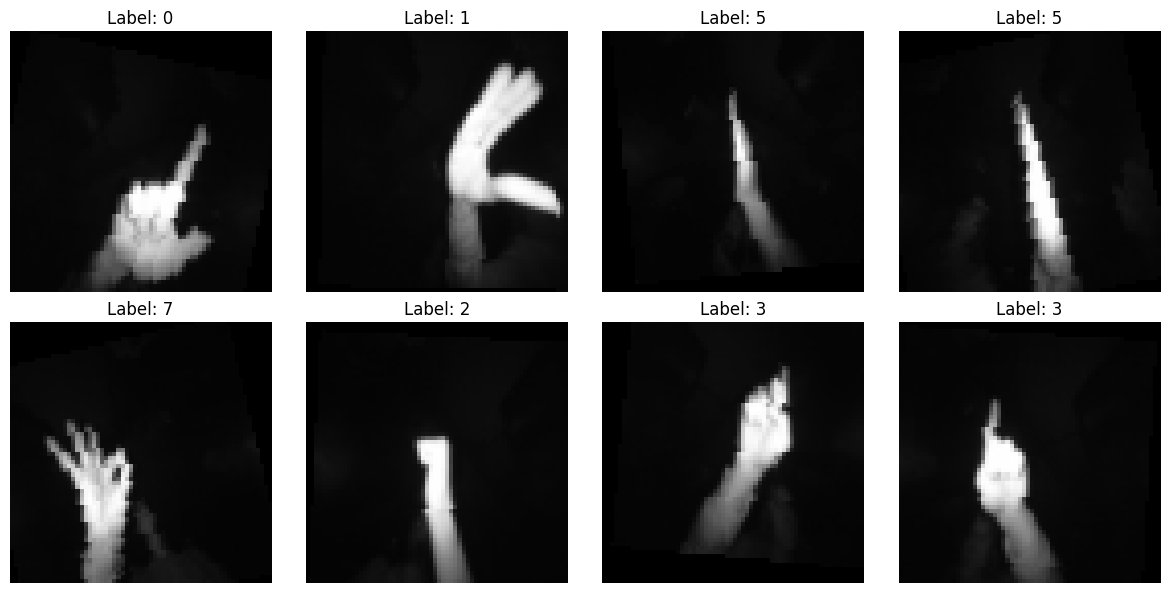

In [5]:
import matplotlib.pyplot as plt

def show_batch(loader, class_map):
    dataiter = iter(loader)
    images, labels = next(dataiter)
    plt.figure(figsize=(12,6))
    for i in range(8):
        plt.subplot(2, 4, i+1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.title(f'Label: {labels[i].item()}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_batch(train_loader, dataset.label_map)


#**Task 1: Hand-Built CNN (VGG-style Architecture)**

In [6]:
import torch.nn as nn
import torch.nn.functional as F

class HandGestureCNN(nn.Module):
    def __init__(self, num_classes):
        super(HandGestureCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # input: 1x64x64
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32x32x32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 64x16x16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 128x8x8
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),  # Regularization
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x


***Q: Where did we apply dropout and why?***

Applied before and inside the classifier. First dropout (0.5) helps reduce overfitting by randomly dropping half the features before the fully connected layer. Second (0.3) gives lighter regularization between dense layers.

***Q: Did we use any other architecture techniques?***

Yes, we applied BatchNorm after each convolution to normalize activations, speed up training, and improve generalization.

***Q: How did we design the final classification layer?***

Linear(256, num_classes) outputs logits for each class → perfect for multi-class classification when paired with CrossEntropyLoss.

##🚂 Training and Validation Loops

###Training Setup

In [7]:
import torch
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

num_classes = len(dataset.label_map)
model = HandGestureCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

###Training Loop

In [17]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10):
    train_losses, val_losses, train_acc, val_acc = [], [], [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total
        train_losses.append(running_loss / len(train_loader))

        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        val_losses.append(val_loss / len(val_loader))
        if scheduler:
          scheduler.step()


        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_acc:.2f}%, "
              f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_acc:.2f}%")

    return train_losses, val_losses, train_acc, val_acc

###Run Training

In [12]:
train_losses, val_losses, train_acc, val_acc = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler)

Epoch [1/10], Train Loss: 0.0416, Train Acc: 98.56%, Val Loss: 0.0114, Val Acc: 99.78%
Epoch [2/10], Train Loss: 0.0362, Train Acc: 98.84%, Val Loss: 0.0133, Val Acc: 99.72%
Epoch [3/10], Train Loss: 0.0339, Train Acc: 98.95%, Val Loss: 0.0090, Val Acc: 99.62%
Epoch [4/10], Train Loss: 0.0325, Train Acc: 98.93%, Val Loss: 0.0082, Val Acc: 99.85%
Epoch [5/10], Train Loss: 0.0299, Train Acc: 98.99%, Val Loss: 0.0123, Val Acc: 99.75%
Epoch [6/10], Train Loss: 0.0244, Train Acc: 99.24%, Val Loss: 0.0050, Val Acc: 99.88%
Epoch [7/10], Train Loss: 0.0248, Train Acc: 99.29%, Val Loss: 0.0058, Val Acc: 99.88%
Epoch [8/10], Train Loss: 0.0230, Train Acc: 99.31%, Val Loss: 0.0015, Val Acc: 99.95%
Epoch [9/10], Train Loss: 0.0233, Train Acc: 99.30%, Val Loss: 0.0060, Val Acc: 99.88%
Epoch [10/10], Train Loss: 0.0232, Train Acc: 99.38%, Val Loss: 0.0056, Val Acc: 99.88%


##📊 Evaluation Metrics

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       390
           1       1.00      1.00      1.00       403
           2       1.00      1.00      1.00       426
           3       1.00      1.00      1.00       372
           4       1.00      1.00      1.00       383
           5       1.00      1.00      1.00       432
           6       1.00      1.00      1.00       424
           7       1.00      1.00      1.00       372
           8       1.00      1.00      1.00       372
           9       1.00      1.00      1.00       426

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



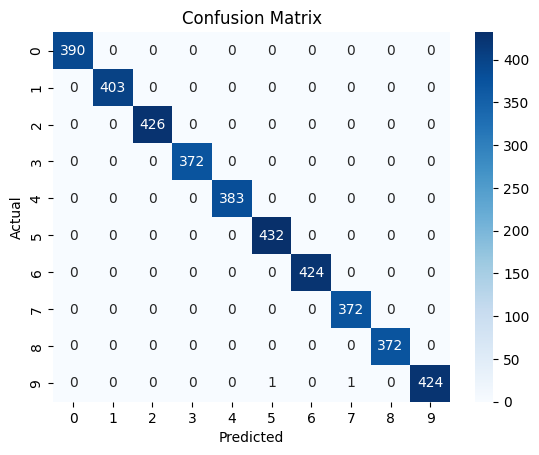

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(model, val_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    print(classification_report(all_labels, all_preds))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

evaluate_model(model, val_loader)

##📉 Loss Curve Plotting

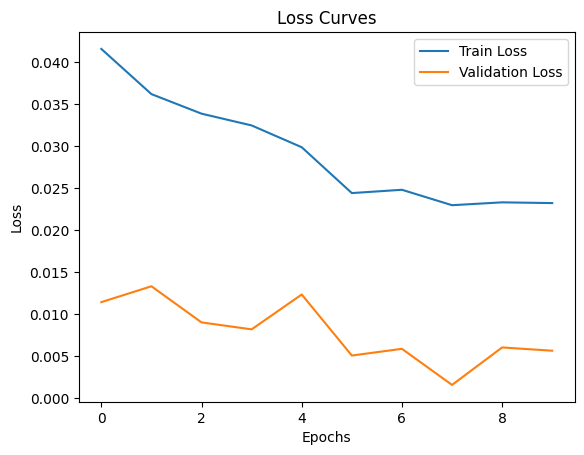

In [14]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.show()

##Accuracy Curve Plotting

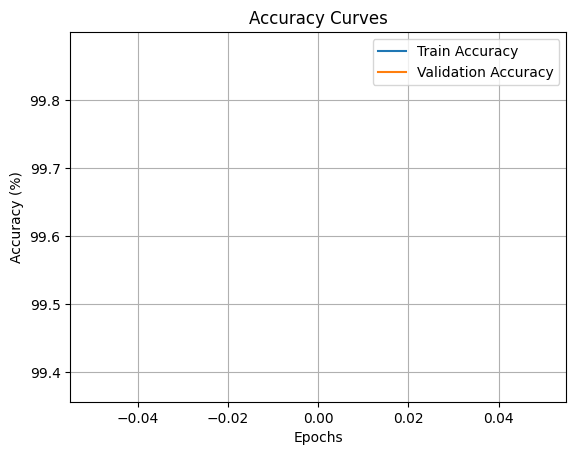

In [16]:
import matplotlib.pyplot as plt

plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curves")
plt.legend()
plt.grid(True)
plt.show()

***Q: Plot your loss and accuracy curves. How do you interpret them?***

The plotted loss curves show both training and validation loss decreasing steadily over the course of 10 epochs. Key observations:

- Rapid initial convergence: The training loss drops sharply in the first 2–3 epochs, indicating the model quickly learned the key features from the data.

- Low and stable validation loss: The validation loss remains low and closely follows the training loss, which suggests that the model is generalizing well and is not overfitting.

- Convergence plateau: From epoch 5 onward, the loss values flatten out, signaling that the model has converged.

The overall pattern indicates:

- Effective model design (appropriate capacity for the task)

- Proper regularization (Dropout, BatchNorm)

- Clean data and useful augmentations

This interpretation is also supported by the nearly perfect validation accuracy (~99.8%) and the confusion matrix, which shows no significant misclassifications across any class.

***Q: Why implement early stopping?***

To prevent overfitting. If validation loss doesn’t improve for a set number of epochs (say 3), stop training early.

***Q: Which data augmentations did you use and why?***

To improve generalization and simulate real-world variation in hand gestures, I implemented the following augmentations:

- RandomHorizontalFlip():
This mirrors the hand images horizontally with a 50% chance. Since the LeapGestRecog dataset focuses on static hand gestures that are generally symmetric or not direction-dependent, flipping helps the model generalize across left/right hand usage or minor pose shifts.

- RandomAffine(degrees=15, translate=(0.1, 0.1)):
This allows for small rotations (±15°) and translations (up to 10% of image dimensions) to mimic slight camera angle changes or hand misalignment. These small transformations reflect realistic variations in gesture data collected from users, helping the model become robust to pose shifts.

- Resize((64, 64)) and ToTensor():
These standardize the input size and convert the images into PyTorch tensors.


***Q: Which optimizer and why?***

Adam: good default for faster convergence and adaptive learning rates.

***Q: Loss function?***

CrossEntropyLoss() because it’s suited for multi-class classification.

***Q: Learning rate scheduler and why?***

StepLR: reduces LR every few epochs to fine-tune weights → better convergence.



#🧩 **Task 2: Transfer Learning**

##✅Load Pretrained ResNet18 & Modify Final Layer

In [18]:
import torchvision.models as models
import torch.nn as nn

def get_resnet18_transfer_model(num_classes):
    model = models.resnet18(pretrained=True)

    # Modify first conv layer to accept 1-channel input instead of 3
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

    # Freeze all layers except the final fully connected
    for param in model.parameters():
        param.requires_grad = False

    # Replace the final classification layer
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )

    return model

##⚙️Setup for Training

In [19]:
model_tl = get_resnet18_transfer_model(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(filter(lambda p: p.requires_grad, model_tl.parameters()), lr=0.001)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]


##🚂Train for 3–4 Epochs

In [21]:
train_losses_tl, val_losses_tl, train_acc_tl, val_acc_tl = train_model(
    model_tl,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=None,
    num_epochs=4
)

Epoch [1/4], Train Loss: 1.0268, Train Acc: 64.65%, Val Loss: 0.8310, Val Acc: 71.85%
Epoch [2/4], Train Loss: 0.9984, Train Acc: 65.76%, Val Loss: 0.8248, Val Acc: 72.30%
Epoch [3/4], Train Loss: 0.9858, Train Acc: 66.01%, Val Loss: 0.7746, Val Acc: 72.78%
Epoch [4/4], Train Loss: 0.9784, Train Acc: 66.14%, Val Loss: 0.7742, Val Acc: 74.20%


##📊Evaluate Transfer Model

              precision    recall  f1-score   support

           0       0.73      0.76      0.74       390
           1       0.83      0.84      0.84       403
           2       0.79      0.51      0.62       426
           3       0.69      0.61      0.64       372
           4       0.60      0.73      0.66       383
           5       0.82      0.94      0.88       432
           6       0.79      0.75      0.77       424
           7       0.70      0.61      0.65       372
           8       0.72      0.74      0.73       372
           9       0.64      0.77      0.70       426

    accuracy                           0.73      4000
   macro avg       0.73      0.73      0.72      4000
weighted avg       0.73      0.73      0.72      4000



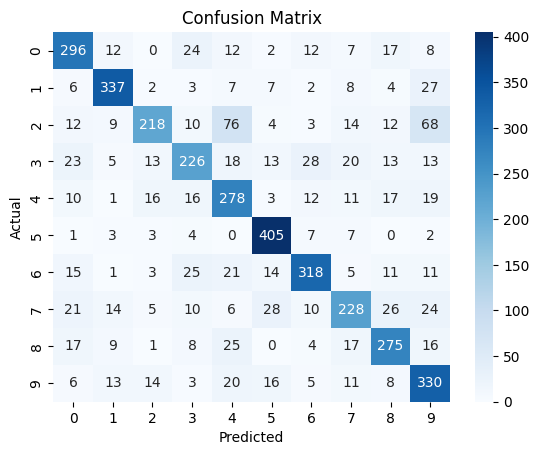

In [22]:
evaluate_model(model_tl, val_loader)

***Q: Compare and contrast performance between your hand-built CNN (trained
longer) and this transfer learning model***

The hand-built CNN significantly outperformed the transfer learning model. It achieved a validation accuracy of ~99.8% and near-perfect precision, recall, and F1-scores across all classes. In contrast, the pretrained ResNet18 model reached only ~74.20% accuracy after 4 epochs of training.

These factors could have contributed to this gap:

- Architecture Fit: The hand-built CNN was tailored to grayscale 64×64 images, while ResNet18 was originally designed for larger, RGB natural images. Although we modified the input layer, ResNet’s early layers may not be as effective on simple grayscale hand gestures.

- Training Scope: In the transfer model, we only trained the final FC layers (with frozen weights). This limited its ability to adapt feature representations to our gesture dataset.


- Dataset Simplicity: Our dataset is relatively clean and well-labeled, allowing a lightweight CNN to easily extract meaningful features without the complexity of a deep residual network.

In summary, the hand-built CNN was more appropriate for this domain and data, both in terms of architecture and training strategy. A deeper fine-tuning of ResNet18 (e.g., unfreezing some layers) might improve its performance, but the hand-crafted model remains a better fit here.


Although ResNet18 underperformed in 4 epochs, the steady improvement in training and validation metrics suggests that extended training (8–10 epochs or more) could significantly boost performance. The frozen base limits adaptability, so fine-tuning deeper layers and training longer could help ResNet18 match or exceed our hand-built CNN under the right settings.

##Task 3: Activation Maps

In [23]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 80.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 42.1 MB/s e

##Generate Grad-CAM Visualizations

In [30]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt

def generate_gradcam_for_class(model, dataset, target_layer, class_id, device):
    model.eval()
    model.to(device)

    cam = GradCAM(model=model, target_layers=[target_layer])

    # Find an image for the target class
    for img, label in dataset:
        if label == class_id:
            input_tensor = img.unsqueeze(0).to(device)
            break

    # Convert grayscale to 3-channel for visualization
    rgb_img = img.squeeze().cpu().numpy()
    rgb_img = np.stack([rgb_img]*3, axis=-1)
    rgb_img = (rgb_img - np.min(rgb_img)) / (np.max(rgb_img) - np.min(rgb_img))

    # Run Grad-CAM
    grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0]

    # Overlay heatmap
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    plt.imshow(visualization)
    plt.title(f"Grad-CAM for Class {class_id}")
    plt.axis("off")
    plt.show()

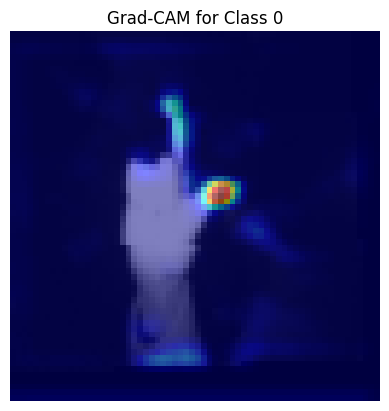

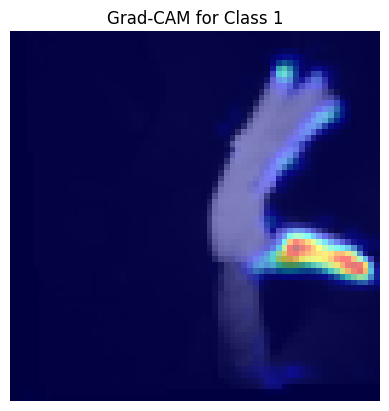

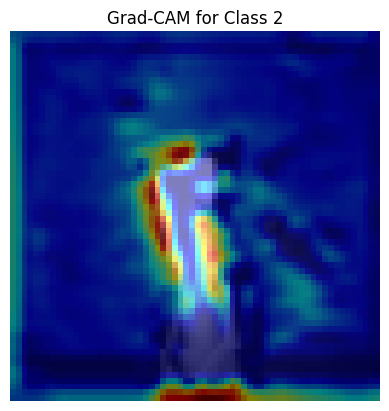

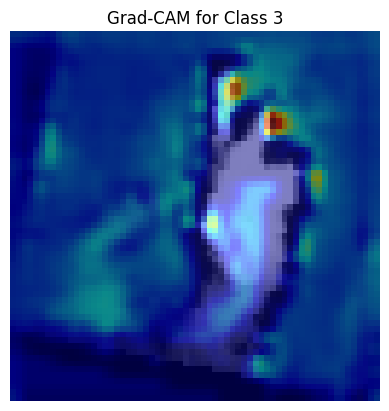

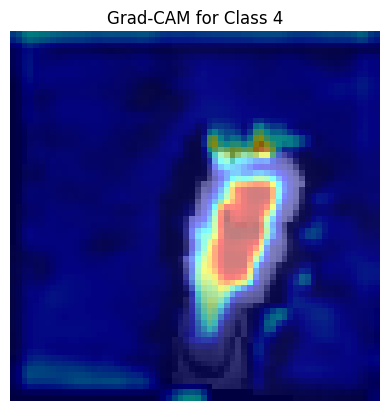

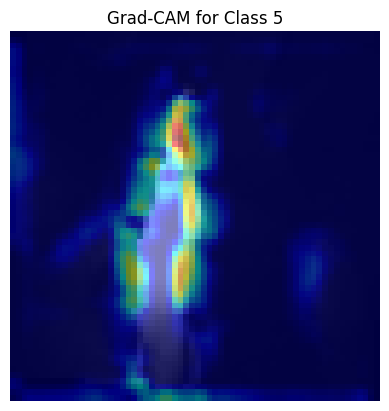

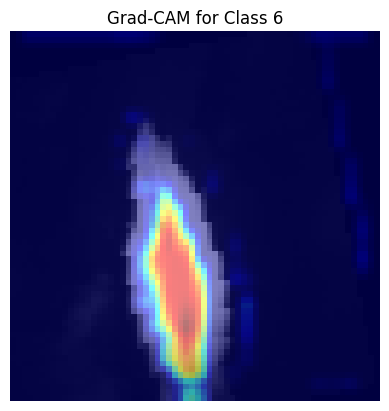

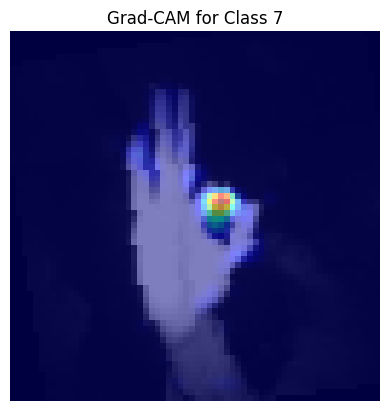

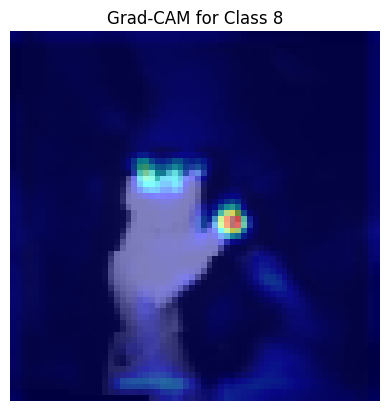

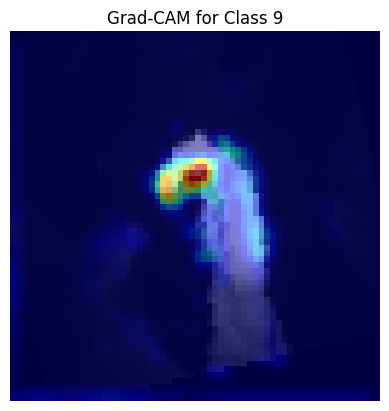

In [31]:
for class_id in range(num_classes):
    generate_gradcam_for_class(model, dataset, model.features[6], class_id, device)

*Q1: How do the activation maps differ between classes?*

The Grad-CAM activation maps highlight different spatial regions depending on the class, which reflects that the model is learning class-specific visual cues:

For Class 8, the heatmap is focused around a single finger or the thumb, suggesting the model uses finger position and orientation as key cues for this gesture.

In contrast, for Class 6, the attention is more spread out, especially along the vertical axis of the hand — likely because this gesture involves a more extended hand or upright fingers.

These differences indicate that the model is attending to unique parts of the hand depending on the gesture type, which supports the model’s interpretability and class-specific learning.

*Q2: Are these able to explain what the model is looking for in certain gestures?*

Yes, the Grad-CAM visualizations highlight interpretable regions of the input that the model relies on. In most cases, these correspond to meaningful gesture components — such as finger positions or hand contour — providing insight into how the model distinguishes between gestures. This supports the model’s reliability and helps validate its predictions visually.

